# California House Price Prediction Using Machine Learning

## *Project Objective*

The objective of this project is to predict California housing  prices using machine learning techniques. This project involves data analytics, preprocessing, model training, and evaluation to build ana accurate prediction model.

## *Importing Libraries*









In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  *Loading the California Housing Dataset*

In [4]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## *Dataset Overview*

In [5]:
df.shape

(20640, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# Cailfornia Housing Price Prediction
## *Exploratory Data Analysis*

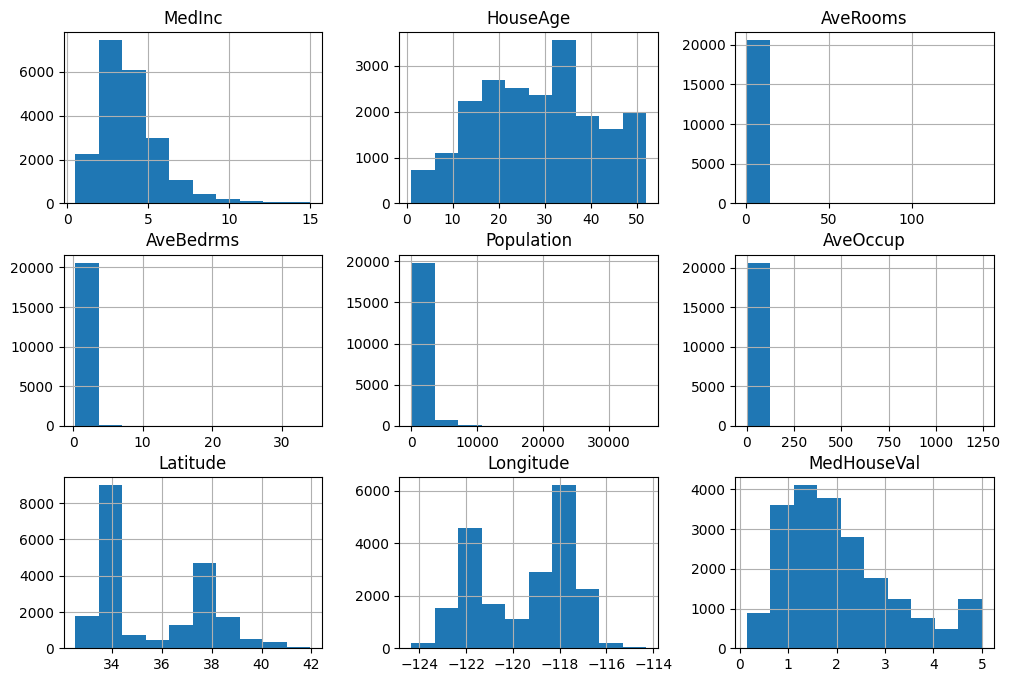

In [7]:
df.hist(figsize=(12,8))
plt.show()

### *Key Observations*
• Median Income appears positively related to housing prices.
• HouseAge shows a wide distribution across the dataset.
• Some features contain skewed distributions.
• The dataset appears suitable for regression modeling.

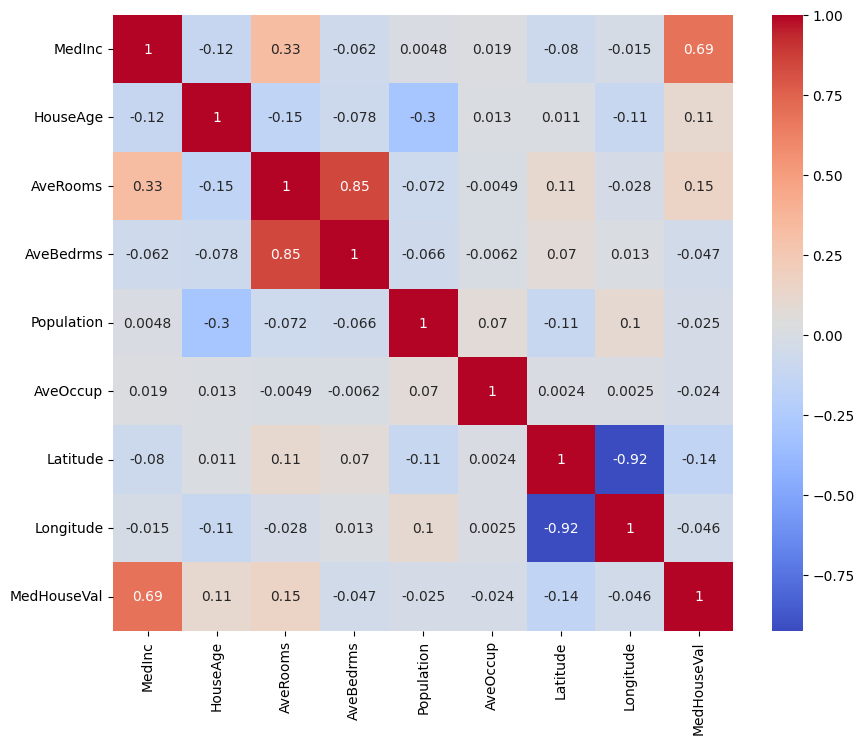

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

### *Correlation Insights*
• Median Income appears positively related to housing prices.
• HouseAge shows a wide distribution across the dataset.
• Some features contain skewed distributions.
• The dataset appears suitable for regression modeling.

## *Feature Selection and Train-Test split*

In [9]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


### ***Linear Regression Model***

In [12]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = lr_model.predict(X_test)

In [28]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R^2 Score:", r2)

R^2 Score: 0.5757877060324508


## ***Random Forest Regression*** ***Model***

In [14]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# ***Prediction***

In [15]:
rf_pred = rf_model.predict(X_test)

In [22]:
from sklearn.metrics import r2_score

In [23]:
rf_r2 = r2_score(y_test, rf_pred)
print("Random Forest R2 Score:", rf_r2)

Random Forest R2 Score: 0.8051230593157366


  *R^2 score*

## Model Comparison

- Linear Regression R^2 Score = 0.5758
- Random Forest R^2 Score = 0.8051

## Conclusion

Random Forest Regressor outperformed Linear Regression and was selected as the final model for house prediction.

## Feature Importance Analysis

In [24]:
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


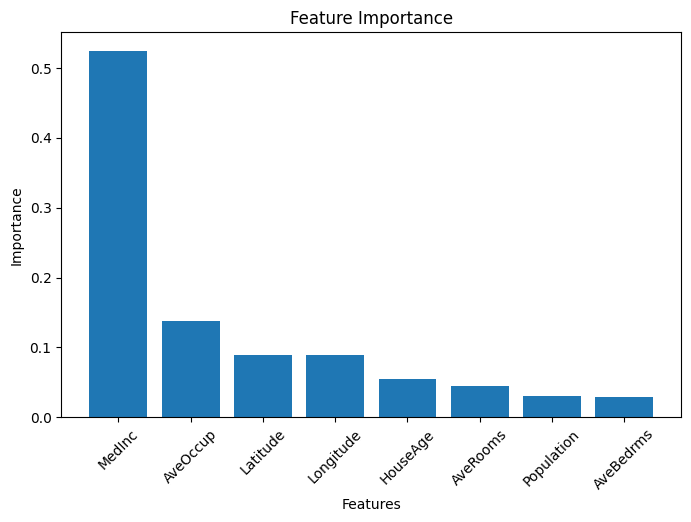

In [26]:
plt.figure(figsize=(8,5))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()

## Actual vs Predicted Prices

1.   List item
2.   List item



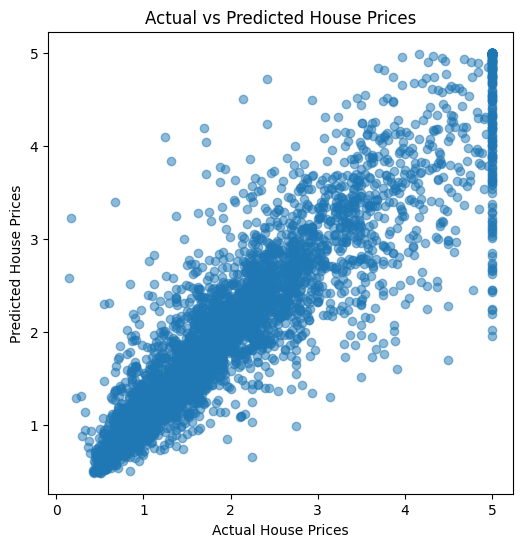

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

## Final Conclusion
This project aimed to predict California housing prices using machine learning techniques.

Two models were trained and evaluated:

• Linear Regression (R² = 0.5758)
• Random Forest Regression (R² = 0.8051)

The Random Forest model significantly outperformed Linear Regression and achieved better predictive performance.

Feature importance analysis revealed that Median Income (MedInc) was the most influential factor affecting housing prices.

Therefore, Random Forest Regression was selected as the final model for California housing price prediction.